# Wow, we now have 2 outputs to compare:
- generated structures using single-property (pchemble values) chemprop mode
- generated structures using multi-property (pchemble values, alogp, hba, psa, etc..)

Just from our previous work, it's clear that training a chemprop model with multiple properties yields a more accurate predictive model.

**So now, let's compare the structures generated by ChemTSV2!**

In [31]:
!pip install rdkit

In [32]:
import pandas as pd
from rdkit import Chem

In [67]:
single_gen_output = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/TRPV1-drug-discovery-research/generation_outputs/result_C1.0_single.csv')
single_gen_output.shape

(507, 11)

In [66]:
multi_gen_output = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/TRPV1-drug-discovery-research/generation_outputs/result_C1.0-multi.csv')
multi_gen_output.shape

(501, 11)

In [40]:
ordered_single_gen_output = single_gen_output.sort_values(by=['reward'], ascending=False)
ordered_single_gen_output.head(10)

,generated_id,smiles,reward,depth,elapsed_time,is_through_filter,predict_trpv1_receptivity,predict_mor_receptivity,predict_dor_receptivity,predict_kor_receptivity,predict_nociceptin_receptivity
53,89,N[C@H](c1ccoc1)C(F)(F)F,0.334995,2,52.7,1,7.747783,2.971163,2.965521,6.033619,5.621036
443,984,O=S(=O)(c1ccccc1Cn1cnc([N+](=O)[O-])n1)N1CCCCC1,0.271649,9,464.5,1,8.013264,5.225637,5.953475,4.224924,5.783046
128,267,c1csc(-c2nnc(-c3cccs3)o2)c1,0.271010,7,129.6,1,7.718602,5.035240,3.283417,4.166620,7.548716
85,173,O=c1[nH]c2cccnc2n1-c1cccc(C(F)(F)F)c1,0.267610,3,84.6,1,7.774595,4.227642,4.924847,4.789536,6.451976
303,658,N[C@H](CO)c1cc(C(F)(F)F)ccc1F,0.263436,4,310.0,1,6.862263,3.164596,4.330971,5.428619,3.987437
6,14,c1ccc(-c2csc(N(CC(=O)[O-])c3nc4ccccc4s3)n2)cc1,0.259549,1,11.8,1,6.717068,4.351745,4.830324,3.299741,4.004515
431,964,O=S(=O)(c1ccc2oc(=S)[nH]c2c1)N1CCOCC1,0.254472,9,464.5,1,7.388795,4.044942,4.422114,4.730346,6.178884
94,195,O[C@@H](COc1ccc(Br)cc1C(F)(F)F)C(F)(F)F,0.242334,4,94.7,1,7.058408,4.011188,4.466600,3.745589,6.316907
271,584,c1cnc(F)cc1CSC1=NS(=O)(=O)c2ccccc21,0.228165,7,281.8,1,7.406801,4.231830,4.037825,5.284652,6.946308
355,768,CCOC(=O)CSc1nnc2sc3cccc(C)c3cc12,0.226636,3,367.1,1,6.923357,4.409153,2.884427,4.289525,7.044904


In [50]:
ordered_multi_gen_output = multi_gen_output.sort_values(by=['reward'], ascending=False)
ordered_multi_gen_output.head(10)

,generated_id,smiles,reward,depth,elapsed_time,is_through_filter,predict_trpv1_receptivity,predict_mor_receptivity,predict_dor_receptivity,predict_kor_receptivity,predict_nociceptin_receptivity
261,715,O=c1oc(-c2ccccc2)nc2cc(-c3ccccc3)nn12,0.319090,5,275.7,1,7.013908,4.519706,3.447520,2.314433,5.010371
386,989,O[C@H](c1cncc(Br)c1)c1cc([N+](=O)[O-])ccc1N1CCCC1,0.265568,7,405.3,1,7.769530,5.093999,4.568190,4.380165,6.413057
78,157,O=S(=O)([N-]c1nc2c(F)cccc2s1)c1ccccc1F,0.260481,3,85.2,1,7.738207,4.939100,5.549231,4.510792,5.534481
281,752,F[C@H](F)[C@@H](F)c1cc(F)c(F)c(F)c1F,0.260305,6,292.7,1,6.937162,6.068960,2.944457,2.890287,5.432727
174,449,COc1ccccc1-c1nnc(NC(=O)c2cccc(S(=O)(=O)N3CCCC3...,0.243021,3,182.1,1,7.661508,4.825834,4.709004,5.316654,6.073698
323,848,O[C@@H](c1cc(F)c(F)c(F)c1)c1ccc(Br)o1,0.239740,6,335.1,1,7.721477,5.169322,5.109506,5.010277,6.007209
398,1020,Fc1cc(F)cc([N-]S(=O)(=O)c2cccc(F)c2)c1F,0.230448,7,433.6,1,7.648508,4.678637,5.424261,5.301393,5.971837
276,740,F[C@H](F)[C@H](F)c1cc(-c2ccc(F)cc2)on1,0.221441,6,292.7,1,6.941429,4.260899,5.413828,4.743977,4.489361
0,2,Nc1cccc(S(=O)(=O)Nc2nc(-c3cccs3)cs2)c1,0.218578,1,17.4,1,6.950725,4.476835,5.222742,3.430378,5.929843
413,1048,Fc1cc(Cl)c(O)c(Cc2ccc3ccccc3n2)c1,0.216201,7,433.6,1,7.624535,5.728354,4.708746,5.719402,5.693607


### Let's view the generated compounds by the single property trained prediction models:

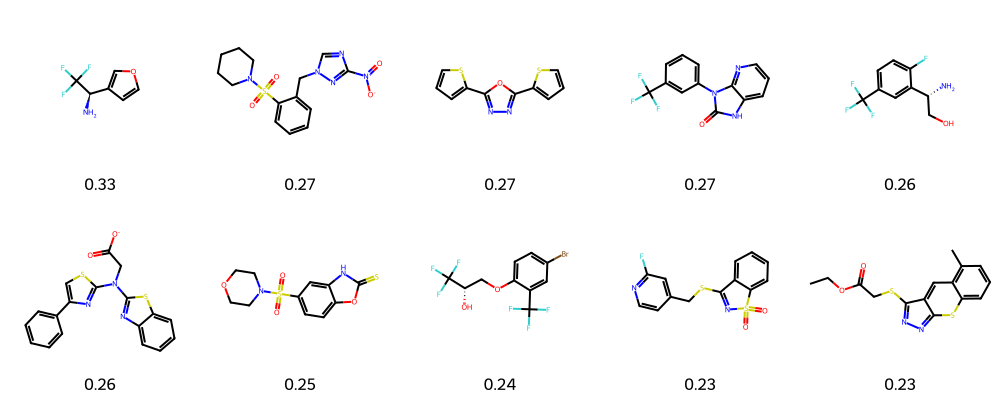

In [72]:
mols = [Chem.MolFromSmiles(s) for s in ordered_single_gen_output['smiles'][:10]]
legends = [str(round(x, 2)) for x in ordered_single_gen_output['reward'][:10]]
Chem.Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(200, 200), legends=legends)

### Let's view the generated compounds by the multi property trained prediction models:

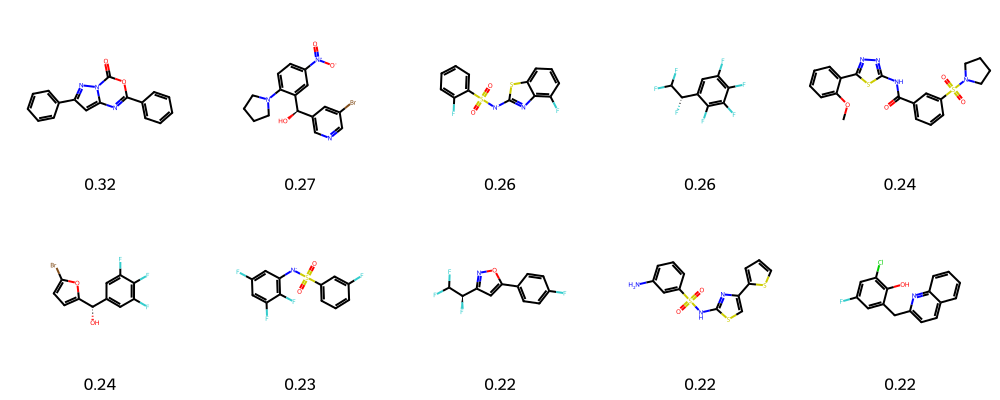

In [45]:
mols = [Chem.MolFromSmiles(s) for s in ordered_multi_gen_output['smiles'][:10]]
legends = [str(round(x, 2)) for x in ordered_multi_gen_output['reward'][:10]]
Chem.Draw.MolsToGridImage(mols, molsPerRow=5, subImgSize=(200, 200), legends=legends)

### Any room for improvement? Absolutely!!!
Before considering further steps, let's state our current progress as of 3/14/2026 (notebooks/steps #00 - #14)

- Q. Is the multi-property prediction models more accurate? And is it preferred?
  - A. Yes, from now on we will only be building multi-property prediction models as that accuracy will guide the generative model to produce better scoring compounds.

- Q. What is the current grading system?
  - A. Refer to step thirteen in the file pchembl_reward.py function: `calc_reward_from_objective_values`
  - Essentially, we are predicting the potency of the generated TRPV1 agonist using our trained model as a positive score. But the other 4 models for opioid receptors will negatively affect the score should the agonist score high on any of them. **We subtract the average positive score (TRPV1) with the average of the negative score (MOR, DOR, KOR, Nociceptin).**
  - Here is the code:
  ```def calc_reward_from_objective_values(values, conf):
    max_pchemble_val = 10 # lets arbitrarily set max score to 10

    # all values
    trpv1_pchembl_pred = values[0]
    mor_pchembl_pred = values[1]
    dor_pchembl_pred = values[2]
    kor_pchembl_pred = values[3]
    nociceptin_pchembl_pred = values[4]

    # positive criteria - get all favorable traits
    trpv1_score = trpv1_pchembl_pred / max_pchemble_val

    # negative criteria - get all unfavorable traits
    negative_scores = []
    mor_score = mor_pchembl_pred / max_pchemble_val
    dor_score = dor_pchembl_pred / max_pchemble_val
    kor_score = kor_pchembl_pred / max_pchemble_val
    nociceptin_score = nociceptin_pchembl_pred / max_pchemble_val

    # store positive scores in array
    positive_scores = []
    positive_scores.append(trpv1_score)

    # store negative scores in array
    negative_scores = []
    negative_scores.append(mor_score)
    negative_scores.append(dor_score)
    negative_scores.append(kor_score)
    negative_scores.append(nociceptin_score)

    positive_sum = sum(positive_scores) / len(positive_scores)
    negative_sum = sum(negative_scores) / len(negative_scores)

    sum_of_scores = positive_sum - negative_sum
    return sum_of_scores
    ```

- Q. Any other parameters we should consider playing with in the generative model?
  - A. Refer to step thirteen in the file pchemble_setting.yaml
  - This file has many filters that we can tweak such as ring size, lipinski rules, and number of radicals. I'm quite rusty on my chemistry but these settings should definitely not be overlooked. For example, we may consider disabling the lipinski filter (or part of it) since RTX violates one of its rules in that its molecular weight is greater than 500 Daltons.
  - Here is the code in the file:
  ```
  c_val: 1.0

  # threshold_type: [time, generation_num]
  threshold_type: generation_num
  #hours: 0.01
  generation_num: 500
  output_dir: result/example01
  model_setting:
    model_json: model/model.tf25.json
    model_weight: model/model.tf25.best.ckpt.h5
  token: model/tokens.pkl
  reward_setting:
    reward_module: reward.pchemble_reward
    reward_class: pchemble_reward

  # Advanced setting
  expansion_threshold: 0.995
  simulation_num: 3
  flush_threshold: -1
  policy_setting:
    policy_module: policy.ucb1
    policy_class: Ucb1

  # Restart setting
  save_checkpoint: False
  restart: False
  checkpoint_file: chemtsv2.ckpt.pkl

  # Filter setting
  use_lipinski_filter: True
  lipinski_filter:
    module: filter.lipinski_filter
    class: LipinskiFilter
    type: rule_of_5
  use_radical_filter: True
  radical_filter:
    module: filter.radical_filter
    class: RadicalFilter
  use_pubchem_filter: True
  pubchem_filter:
    module: filter.pubchem_filter
    class: PubchemFilter
  use_sascore_filter: True
  sascore_filter:
    module: filter.sascore_filter
    class: SascoreFilter
    threshold: 3.5
  use_ring_size_filter: True
  ring_size_filter:
    module: filter.ring_size_filter
    class: RingSizeFilter
    threshold: 6
  use_pains_filter: False
  pains_filter:
    module: filter.pains_filter
    class: PainsFilter
    type: [pains_a]
  use_covalent_warhead_filter: False
  covalent_warhead_filter:
    module: filter.covalent_warhead_filter
    class: CovalentWarheadFilter
  include_filter_result_in_reward: False
  ```


## What now?
- As you can see from the top scoring compounds from both datasets, its quite clear that the score doesn't even reach 0.5. The highest scoring compound is 0.33. Possible options to increase this score is to:
  - train better predictive models with more data by including other databases such as PubChem.
  - tweak the settings for the generative model. Currently the default enables all filters which limits the "creativity" of the generative model.
  - introduce other positive grading models such as building predictive models similar to TRPV1 (such as TRPV5).

### Below are some other simple stats we can gather from the top 10 scoring compounds:

In [63]:
# average TRPV1 potency prediction from both models
ordered_single_gen_output.head(10)['reward'].mean(), ordered_multi_gen_output.head(10)['reward'].mean()

(np.float64(0.2619854646921158), np.float64(0.24748717904090878))

In [64]:
# max TRPV1 potency prediction from both models
ordered_single_gen_output.head(10)['reward'].max(), ordered_multi_gen_output.head(10)['reward'].max()

(0.3349947810173035, 0.3190900802612305)

In [65]:
# min TRPV1 potency prediction from both models
ordered_single_gen_output.head(10)['reward'].min(), ordered_multi_gen_output.head(10)['reward'].min()

(0.2266355276107788, 0.2162007331848144)